In [1]:
!python --version

Python 3.11.14


In [2]:
import os, sys
import pandas as pd

from pathlib import Path

ROOT = Path().resolve().parent.parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.calc_degs_lib import CALC_DEGS
from libs.tcga_gdc_lib import *
from libs.Basic import *


ROOT: /home/flavio/uv
SRC added: /home/flavio/uv/src


### Defaults

In [3]:
ROOT = Path().resolve().parent
root_data = os.path.join(ROOT, "data/tcga")

gdc = GDC(root_data=root_data)

os.listdir(root_data)[:10]


['subtype_for_TCGA-KIRC.tsv',
 'samples_for_TCGA-STAD_Stomach_subtype_adenocarcinoma_generic_tumor_adenocarcinoma_subtype_tissue_adenocarcinoma_generic.tsv',
 'mutations_anal_for_study_TCGA-KIRC_Kidney_subtype_adenocarcinoma_generic_tumor_adenocarcinoma_subtype_tissue_adenocarcinoma_generic.tsv',
 'mutations_anal_for_study_TCGA-THCA_Thyroid_gland_subtype_other_tumor_other_subtype_tissue_other.tsv',
 'mutations_summ_for_study_TCGA-UCS_Uterus_NOS_Corpus_uteri_subtype_other_tumor_melanoma_subtype_tissue_other.tsv',
 'mutations_summ_for_study_TCGA-GBM_Brain_subtype_other_tumor_other_subtype_tissue_other.tsv',
 'mutations_anal_for_study_TCGA-LUAD_Bronchus_and_lung_subtype_other_tumor_other_subtype_tissue_other.tsv',
 'mutations_anal_for_study_TCGA-CHOL_Liver_and_intrahepatic_bile_ducts_Other_and_unspecified_parts_of_biliary_tract_Pancreas_subtype_sarcoma_tumor_sarcoma_subtype_tissue_sarcoma.tsv',
 'mutations_anal_for_study_TCGA-CHOL_Liver_and_intrahepatic_bile_ducts_Other_and_unspecified_pa

### Get all programs

In [4]:
force=False
verbose=True

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)


File read at '/home/flavio/uv/perturb_agent/data/tcga/programs.txt'


In [5]:
np.array(prog_list)

array(['TCGA', 'MATCH', 'TARGET', 'CGCI', 'CMI', 'APOLLO', 'BEATAML1.0',
       'CPTAC', 'MP2PRT', 'ALCHEMIST', 'CCDI', 'CCG', 'CDDP_EAGLE',
       'CTSP', 'EXCEPTIONAL_RESPONDERS', 'FM', 'HCMI', 'MMRF', 'NCICCR',
       'OHSU', 'ORGANOID', 'RC', 'REBC', 'TRIO', 'VAREPOP', 'WCDT'],
      dtype='<U22')

### Primary sites given a program

In [6]:
gdc.url_gdc_project

'https://api.gdc.cancer.gov/projects'

In [7]:
force=False
verbose=False

pid = 'TCGA'

df_all_cases, df_all_samples, df_all_mutations = \
    gdc.loop_program_psi_samples(program=pid, force=force, verbose=verbose)

print("\n----------- end ------------\n")
print(len(df_all_samples))



----------- end ------------

245657


In [8]:
print(len(df_all_cases))
df_all_cases.tail(3)

11428


,primary_site,disease_type,case_id,diagnoses,pid,subtype_global,stage_ajcc,primary_diagnosis,tumor_grade,stage_clin,...,primary_site_norm,disease_type_norm,diagnosis_norm,tumor_class,histology,subtype_tissue,consistency,validity,n,frac
11425,Corpus uteri,"Cystic, Mucinous and Serous Neoplasms",db67a9cd-65ba-4d6f-a799-031b6b3df599,[{'primary_diagnosis': 'Serous cystadenocarcin...,TCGA-UCEC,serous,unknown,"Serous cystadenocarcinoma, NOS",G3,NaN,...,corpus uteri,cystic mucinous and serous neoplasms,serous cystadenocarcinoma,adenocarcinoma,epithelial,uterine_serous,ok,valid,1,0.001786
11426,Corpus uteri,Adenomas and Adenocarcinomas,976bb47a-d999-4e24-ad08-452fea73c846,"[{'primary_diagnosis': 'Clear cell carcinoma',...",TCGA-UCEC,clear_cell,unknown,Clear cell carcinoma,G1,NaN,...,corpus uteri,adenomas and adenocarcinomas,clear cell carcinoma,other,epithelial,uterine_clear_cell,ok,valid,1,0.001786
11427,Corpus uteri,Adenomas and Adenocarcinomas,e604f5d4-f2c0-4404-9073-b8dbc8396778,[{'primary_diagnosis': 'Endometrioid adenocarc...,TCGA-UCEC,endometrioid,unknown,"Endometrioid adenocarcinoma, NOS",G3,NaN,...,corpus uteri,adenomas and adenocarcinomas,endometrioid adenocarcinoma,adenocarcinoma,epithelial,uterine_endometrioid,ok,valid,1,0.001786


In [9]:
print(len(df_all_samples))
df_all_samples.tail(3)

245657


,case_id,submitter_id,sample_id,sample_type,barcode_sample,file_id,file_name,data_type,data_format,pid,subtype_global,tumor_class,subtype_tissue,stage
245654,2fe46394-cfc5-44bb-81a9-e438a0126f5b,TCGA-A5-A1OK,65208656-d7e1-493a-8806-90b4e82d701f,Blood Derived Normal,TCGA-A5-A1OK-10A,c1d633f4-e539-4abd-9ba6-8c67d8b3f474,42f61f26-fbd1-4ecf-b446-980cdd7cdb8e.wxs.aliqu...,Aggregated Somatic Mutation,MAF,TCGA-UCEC,squamous,squamous_cell_carcinoma,squamous,unknown
245655,2fe46394-cfc5-44bb-81a9-e438a0126f5b,TCGA-A5-A1OK,65208656-d7e1-493a-8806-90b4e82d701f,Blood Derived Normal,TCGA-A5-A1OK-10A,37650872-d6af-4211-bd15-b7441ba6c378,0dbc85ff-ee09-467c-81ff-a6184401f7cc.wxs.Pinde...,Annotated Somatic Mutation,MAF,TCGA-UCEC,squamous,squamous_cell_carcinoma,squamous,unknown
245656,2fe46394-cfc5-44bb-81a9-e438a0126f5b,TCGA-A5-A1OK,65208656-d7e1-493a-8806-90b4e82d701f,Blood Derived Normal,TCGA-A5-A1OK-10A,cea3e10a-4c23-473a-8302-2e6a91a2b1dc,CABAL_p_TCGA_b112_125_SNP_N_GenomeWideSNP_6_F0...,Masked Copy Number Segment,TXT,TCGA-UCEC,squamous,squamous_cell_carcinoma,squamous,unknown


In [10]:
barcode_samples = np.unique(df_all_samples.barcode_sample)
len(barcode_samples)

8506

In [11]:
sample_types = np.unique(df_all_samples.sample_type)
sample_types

array(['Additional - New Primary', 'Additional Metastatic',
       'Blood Derived Normal', 'Bone Marrow Normal', 'Buccal Cell Normal',
       'Metastatic', 'Primary Blood Derived Cancer - Peripheral Blood',
       'Primary Tumor', 'Recurrent Tumor', 'Solid Tissue Normal'],
      dtype=object)

In [12]:
df_normal = df_all_samples[df_all_samples.sample_type.str.contains('Normal', case=False, na=False)]
len(df_normal)

98079

In [13]:
symbols = np.unique(df_all_mutations.symbol)
len(symbols)

18957

In [14]:
primary_sites = list(np.unique(df_all_cases.primary_site_norm))
primary_sites.sort()
print(len(primary_sites))

print(", ".join(primary_sites))

57
adrenal gland, anus and anal canal, base of tongue, bladder, bones joints and articular cartilage of limbs, bones joints and articular cartilage of other and unspecified sites, brain, breast, bronchus and lung, cervix uteri, colon, connective subcutaneous and other soft tissues, corpus uteri, esophagus, eye and adnexa, floor of mouth, gum, heart mediastinum and pleura, hematopoietic and reticuloendothelial systems, hypopharynx, kidney, larynx, lip, liver and intrahepatic bile ducts, lymph nodes, meninges, nasal cavity and middle ear, oropharynx, other and ill-defined sites, other and ill-defined sites in lip oral cavity and pharynx, other and unspecified major salivary glands, other and unspecified male genital organs, other and unspecified parts of biliary tract, other and unspecified parts of mouth, other and unspecified parts of tongue, other endocrine glands and related structures, ovary, palate, pancreas, parotid gland, peripheral nerves and autonomic nervous system, prostate g

In [15]:
stri = f"Interfacing GDC {pid} data, one gathered:"
print(stri)
stri = f"\t- {len(primary_sites)} primary sites."
print(stri)
stri = f"\t- {len(df_all_cases)} cases."
print(stri)
stri = f"\t- {len(df_all_samples)} samples."
print(stri)
stri = f"\t- {len(df_all_mutations)} annotated mutations."
print(stri)
stri = f"\t- {len(symbols)} different genes."
print(stri)


Interfacing GDC TCGA data, one gathered:
	- 57 primary sites.
	- 11428 cases.
	- 245657 samples.
	- 750525 annotated mutations.
	- 18957 different genes.


In [16]:
primary_sites = np.array(primary_sites)
primary_sites

array(['adrenal gland', 'anus and anal canal', 'base of tongue',
       'bladder', 'bones joints and articular cartilage of limbs',
       'bones joints and articular cartilage of other and unspecified sites',
       'brain', 'breast', 'bronchus and lung', 'cervix uteri', 'colon',
       'connective subcutaneous and other soft tissues', 'corpus uteri',
       'esophagus', 'eye and adnexa', 'floor of mouth', 'gum',
       'heart mediastinum and pleura',
       'hematopoietic and reticuloendothelial systems', 'hypopharynx',
       'kidney', 'larynx', 'lip', 'liver and intrahepatic bile ducts',
       'lymph nodes', 'meninges', 'nasal cavity and middle ear',
       'oropharynx', 'other and ill-defined sites',
       'other and ill-defined sites in lip oral cavity and pharynx',
       'other and unspecified major salivary glands',
       'other and unspecified male genital organs',
       'other and unspecified parts of biliary tract',
       'other and unspecified parts of mouth',
       

In [17]:

term = 'breast'
term = 'esophagus'

primary_sites[[True if term in x.lower() else False for x in primary_sites]]

array(['esophagus'], dtype='<U68')

In [18]:
df_all_cases.head()

,primary_site,disease_type,case_id,diagnoses,pid,subtype_global,stage_ajcc,primary_diagnosis,tumor_grade,stage_clin,...,primary_site_norm,disease_type_norm,diagnosis_norm,tumor_class,histology,subtype_tissue,consistency,validity,n,frac
0,Adrenal gland,Adenomas and Adenocarcinomas,7e61e3b8-c617-4a5f-afdf-689521c9a670,[{'primary_diagnosis': 'Adrenal cortical carci...,TCGA-ACC,adrenal_cortical_carcinoma,NaN,Adrenal cortical carcinoma,NaN,NaN,...,adrenal gland,adenomas and adenocarcinomas,adrenal cortical carcinoma,adrenal_cortical_carcinoma,other,adrenal_cortical_carcinoma,ok,valid,1,0.01087
1,Adrenal gland,Adenomas and Adenocarcinomas,09454ed6-64bc-4a35-af44-7c4344623d45,[{'primary_diagnosis': 'Adrenal cortical carci...,TCGA-ACC,adrenal_cortical_carcinoma,NaN,Adrenal cortical carcinoma,NaN,NaN,...,adrenal gland,adenomas and adenocarcinomas,adrenal cortical carcinoma,adrenal_cortical_carcinoma,other,adrenal_cortical_carcinoma,ok,valid,1,0.01087
2,Adrenal gland,Adenomas and Adenocarcinomas,4f845fea-e823-47d6-89fb-36ee478a43b8,[{'primary_diagnosis': 'Adrenal cortical carci...,TCGA-ACC,adrenal_cortical_carcinoma,NaN,Adrenal cortical carcinoma,NaN,NaN,...,adrenal gland,adenomas and adenocarcinomas,adrenal cortical carcinoma,adrenal_cortical_carcinoma,other,adrenal_cortical_carcinoma,ok,valid,1,0.01087
3,Adrenal gland,Adenomas and Adenocarcinomas,891b7a67-0a01-45f0-8a32-4a1b3e888f6c,[{'primary_diagnosis': 'Adrenal cortical carci...,TCGA-ACC,adrenal_cortical_carcinoma,NaN,Adrenal cortical carcinoma,NaN,NaN,...,adrenal gland,adenomas and adenocarcinomas,adrenal cortical carcinoma,adrenal_cortical_carcinoma,other,adrenal_cortical_carcinoma,ok,valid,1,0.01087
4,Adrenal gland,Adenomas and Adenocarcinomas,a26b6f97-fd7e-4b96-bdf5-9df4f9233726,[{'primary_diagnosis': 'Adrenal cortical carci...,TCGA-ACC,adrenal_cortical_carcinoma,NaN,Adrenal cortical carcinoma,NaN,NaN,...,adrenal gland,adenomas and adenocarcinomas,adrenal cortical carcinoma,adrenal_cortical_carcinoma,other,adrenal_cortical_carcinoma,ok,valid,1,0.01087


In [19]:
disease_type = 'Adenomas and Adenocarcinomas'

df2 = df_all_cases[ (df_all_cases.primary_site_norm.str.contains(term, case=False)) &
                   (df_all_cases.disease_type_norm.str.contains(disease_type, case=False)) ]
df2

,primary_site,disease_type,case_id,diagnoses,pid,subtype_global,stage_ajcc,primary_diagnosis,tumor_grade,stage_clin,...,primary_site_norm,disease_type_norm,diagnosis_norm,tumor_class,histology,subtype_tissue,consistency,validity,n,frac
5558,Esophagus,Adenomas and Adenocarcinomas,29da08f4-c9e2-4e7a-9733-b4ec5b9c5f13,"[{'primary_diagnosis': 'Not Reported'}, {'prim...",TCGA-ESCA,other,unknown,Not Reported,GX,NaN,...,esophagus,adenomas and adenocarcinomas,not reported,other,other,other,ok,invalid,1,0.005405
5560,Esophagus,Adenomas and Adenocarcinomas,6826bcdd-24a4-4dd1-9fab-201cf774e166,"[{'primary_diagnosis': 'Adenocarcinoma, NOS'},...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",GX,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5561,Esophagus,Adenomas and Adenocarcinomas,90940ff1-c270-44f5-9949-f726838aaa57,"[{'primary_diagnosis': 'Adenocarcinoma, NOS', ...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",GX,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5562,Esophagus,Adenomas and Adenocarcinomas,c17331fb-c47b-40b5-8d39-9803ee37a42a,"[{'primary_diagnosis': 'Adenocarcinoma, NOS'},...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",G2,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5563,Esophagus,Adenomas and Adenocarcinomas,b2b8c6bc-509b-4c5b-b0fb-d07a5628fa80,"[{'primary_diagnosis': 'Adenocarcinoma, NOS'},...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",G3,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5735,Esophagus,Adenomas and Adenocarcinomas,ee47cd59-c8d8-4b1e-96db-91c679e4106f,"[{'primary_diagnosis': 'Adenocarcinoma, NOS', ...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",G2,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5737,Esophagus,Adenomas and Adenocarcinomas,f23794d7-35cc-4550-a03f-8e3cde1a2bcd,"[{'primary_diagnosis': 'Adenocarcinoma, NOS'},...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",G3,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5738,Esophagus,Adenomas and Adenocarcinomas,f28f37a0-8e24-4a36-90f0-83cf5a27be10,"[{'primary_diagnosis': 'Adenocarcinoma, NOS', ...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",GX,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405
5740,Esophagus,Adenomas and Adenocarcinomas,fb777a96-2e24-4b60-9c7e-9d5dc3e7f35a,"[{'primary_diagnosis': 'Adenocarcinoma, NOS', ...",TCGA-ESCA,adenocarcinoma_generic,unknown,"Adenocarcinoma, NOS",GX,NaN,...,esophagus,adenomas and adenocarcinomas,adenocarcinoma,adenocarcinoma,epithelial,adenocarcinoma_generic,ok,valid,1,0.005405


In [20]:
case_id_list = np.unique(df2.case_id)
len(case_id_list)

87

In [21]:
sample_type = 'tumor'
df3 = df_all_samples[ (df_all_samples.case_id.isin(case_id_list)) & (df_all_samples.sample_type.str.contains(sample_type, case=False)) ]
print(len(df3))
df3.head(3)

2339


,case_id,submitter_id,sample_id,sample_type,barcode_sample,file_id,file_name,data_type,data_format,pid,subtype_global,tumor_class,subtype_tissue,stage
104523,9e02a368-8858-4ec5-8c27-9e0876d387a4,TCGA-L5-A8NJ,7cf7a9fc-92f8-4072-98bd-59829c10d172,Primary Tumor,TCGA-L5-A8NJ-01A,edd1ed69-5095-44ff-a075-2e5593798a8e,TCGA-ESCA.221d3836-d867-4458-a7f3-108a3b374f77...,Gene Level Copy Number,TSV,TCGA-ESCA,adenocarcinoma_generic,adenocarcinoma,adenocarcinoma_generic,unknown
104524,9e02a368-8858-4ec5-8c27-9e0876d387a4,TCGA-L5-A8NJ,7cf7a9fc-92f8-4072-98bd-59829c10d172,Primary Tumor,TCGA-L5-A8NJ-01A,4f848b21-0903-4114-98c7-5a06a640477a,TCGA_ESCA.b056c63a-e29a-4ae0-9c96-3a9853949333...,Annotated Somatic Mutation,VCF,TCGA-ESCA,adenocarcinoma_generic,adenocarcinoma,adenocarcinoma_generic,unknown
104525,9e02a368-8858-4ec5-8c27-9e0876d387a4,TCGA-L5-A8NJ,7cf7a9fc-92f8-4072-98bd-59829c10d172,Primary Tumor,TCGA-L5-A8NJ-01A,e0f0f5ab-7ff7-4640-9cf6-0172e310256d,3ee213e3-a720-420d-9e59-2bebdf8cb379.rna_seq.g...,Aligned Reads,BAM,TCGA-ESCA,adenocarcinoma_generic,adenocarcinoma,adenocarcinoma_generic,unknown


In [22]:
sample_type_list = np.unique(df3.sample_type)
sample_type_list

array(['Primary Tumor'], dtype=object)

In [31]:
barcode_list = list(np.unique(df3.barcode_sample))

barcode_list = ["-".join(x.split('-')[:-1]) for x in barcode_list]
len(barcode_list)

93

In [32]:
np.array(barcode_list)

array(['TCGA-2H-A9GF', 'TCGA-2H-A9GF', 'TCGA-2H-A9GG', 'TCGA-2H-A9GG',
       'TCGA-2H-A9GH', 'TCGA-2H-A9GH', 'TCGA-2H-A9GK', 'TCGA-2H-A9GK',
       'TCGA-2H-A9GM', 'TCGA-2H-A9GM', 'TCGA-2H-A9GN', 'TCGA-2H-A9GN',
       'TCGA-IC-A6RE', 'TCGA-IG-A4QS', 'TCGA-IG-A4QS', 'TCGA-IG-A7DP',
       'TCGA-IG-A7DP', 'TCGA-JY-A6F8', 'TCGA-JY-A6F8', 'TCGA-JY-A939',
       'TCGA-JY-A939', 'TCGA-JY-A93D', 'TCGA-JY-A93D', 'TCGA-JY-A93E',
       'TCGA-JY-A93E', 'TCGA-L5-A43E', 'TCGA-L5-A43E', 'TCGA-L5-A43I',
       'TCGA-L5-A43M', 'TCGA-L5-A43M', 'TCGA-L5-A4OE', 'TCGA-L5-A4OE',
       'TCGA-L5-A4OF', 'TCGA-L5-A4OF', 'TCGA-L5-A4OG', 'TCGA-L5-A4OG',
       'TCGA-L5-A4OH', 'TCGA-L5-A4OH', 'TCGA-L5-A4OO', 'TCGA-L5-A4OO',
       'TCGA-L5-A4OP', 'TCGA-L5-A4OP', 'TCGA-L5-A4OQ', 'TCGA-L5-A4OQ',
       'TCGA-L5-A4OR', 'TCGA-L5-A4OR', 'TCGA-L5-A4OT', 'TCGA-L5-A4OT',
       'TCGA-L5-A4OW', 'TCGA-L5-A4OW', 'TCGA-L5-A4OX', 'TCGA-L5-A4OX',
       'TCGA-L5-A88T', 'TCGA-L5-A88Y', 'TCGA-L5-A8NE', 'TCGA-L5-A8NG',
      

### Mutations

In [26]:
df_all_mutations.columns

Index(['pid', 'barcode', 'barcode_sample', 'symbol', 'refseq_mrna_id',
       'entrez_gene_id', 'protein_mut', 'mutation_type', 'variant_type', 'chr',
       'n_mutations'],
      dtype='str')

In [33]:
df_all_mutations.barcode.iloc[:4]

0    TCGA-OR-A5J2
1    TCGA-OR-A5J2
2    TCGA-OR-A5J2
3    TCGA-OR-A5J2
Name: barcode, dtype: str

In [34]:
df4 = df_all_mutations[df_all_mutations.barcode.isin(barcode_list)]
len(df4), len(df_all_mutations)

(7680, 750525)

In [35]:
df4.head(3)

,pid,barcode,barcode_sample,symbol,refseq_mrna_id,entrez_gene_id,protein_mut,mutation_type,variant_type,chr,n_mutations
401517,esca_tcga_pan_can_atlas_2018,TCGA-2H-A9GF,TCGA-2H-A9GF-01,AASS,NaN,10157,E368V,Missense_Mutation,SNP,7,1
401518,esca_tcga_pan_can_atlas_2018,TCGA-2H-A9GF,TCGA-2H-A9GF-01,ABCA13,NM_152701.3,154664,R2939C,Missense_Mutation,SNP,7,1
401519,esca_tcga_pan_can_atlas_2018,TCGA-2H-A9GF,TCGA-2H-A9GF-01,ABCB6,NM_005689.2,10058,R584H,Missense_Mutation,SNP,2,1


In [45]:
df4["value"] = True

dfpiv = df4.pivot_table(
            index="barcode",
            columns="symbol",
            values="value",
            aggfunc="max",      # if duplicates exist
            fill_value=False )

# ensure boolean dtype
dfpiv = dfpiv.astype(bool)
print(dfpiv.shape)

Nmin_barcodes=3
Nmin_genes=5

gene_filter = dfpiv.sum(axis=0) >= Nmin_barcodes
dfpiv = dfpiv.loc[:, gene_filter]

barcode_filter = dfpiv.sum(axis=1) >= Nmin_genes
dfpiv = dfpiv.loc[barcode_filter]

print(dfpiv.shape)

dfpiv.iloc[:10,:18]

(51, 4754)
(50, 449)


symbol,ABCA12,ABCA13,ABCA6,ABCC9,ACACB,ACSS3,ACTN2,ADAM32,ADAM7,ADAMTS12,ADAMTS16,ADAMTS19,ADAMTS2,ADGRB1,ADGRB3,ADGRE1,ADGRL2,ADGRV1
barcode,,,,,,,,,,,,,,,,,,
TCGA-2H-A9GF,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
TCGA-2H-A9GH,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-2H-A9GK,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
TCGA-2H-A9GM,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
TCGA-2H-A9GN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-IC-A6RE,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-IG-A4QS,True,False,True,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False
TCGA-JY-A6F8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-JY-A939,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [41]:
df_sparse = dfpiv.astype(pd.SparseDtype("bool", fill_value=False))
df_sparse.iloc[:10,:18]

symbol,A2M,A3GALT2,A4GALT,AAK1,AASDH,AASS,AATK,ABCA1,ABCA12,ABCA13,ABCA2,ABCA3,ABCA6,ABCA8,ABCB1,ABCB4,ABCB6,ABCB9
barcode,,,,,,,,,,,,,,,,,,
TCGA-2H-A9GF,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False
TCGA-2H-A9GH,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-2H-A9GK,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
TCGA-2H-A9GM,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
TCGA-2H-A9GN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-IC-A6RE,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
TCGA-IG-A4QS,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
TCGA-IG-A7DP,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
TCGA-JY-A6F8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
print("Genes kept:", dfpiv.shape[1])
print("Samples kept:", dfpiv.shape[0])

print("\nTop mutated genes:")
print(dfpiv.sum(axis=0).sort_values(ascending=False).head(10))

print("\nMutations per sample:")
print(dfpiv.sum(axis=1).describe())

Genes kept: 449
Samples kept: 50

Top mutated genes:
symbol
TP53     39
TTN      25
CSMD3    16
HMCN1    15
MUC16    14
FLG      13
SYNE1    13
PCLO     13
RYR2     12
LRP1B    12
dtype: int64

Mutations per sample:
count     50.000000
mean      38.080000
std       19.074334
min        8.000000
25%       24.250000
50%       34.500000
75%       50.250000
max      100.000000
dtype: float64


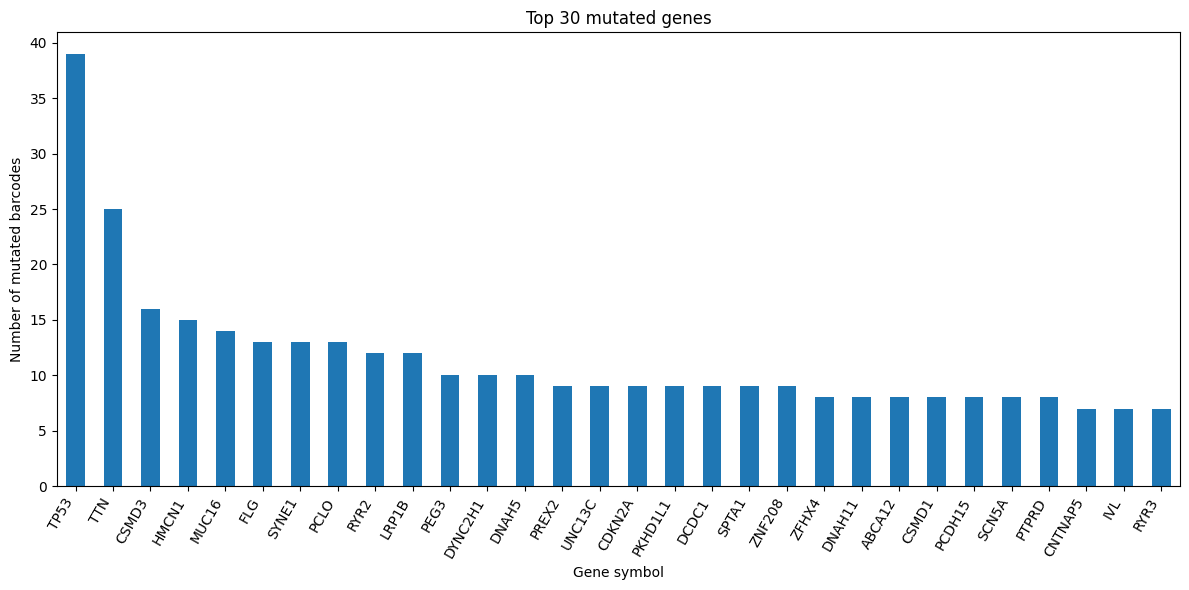

In [48]:
import matplotlib.pyplot as plt

# number of mutated barcodes per gene
gene_counts = dfpiv.sum(axis=0).sort_values(ascending=False)

top_n = 30
top_genes = gene_counts.head(top_n)

plt.figure(figsize=(12, 6))
top_genes.plot(kind="bar")
plt.ylabel("Number of mutated barcodes")
plt.xlabel("Gene symbol")
plt.title(f"Top {top_n} mutated genes")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

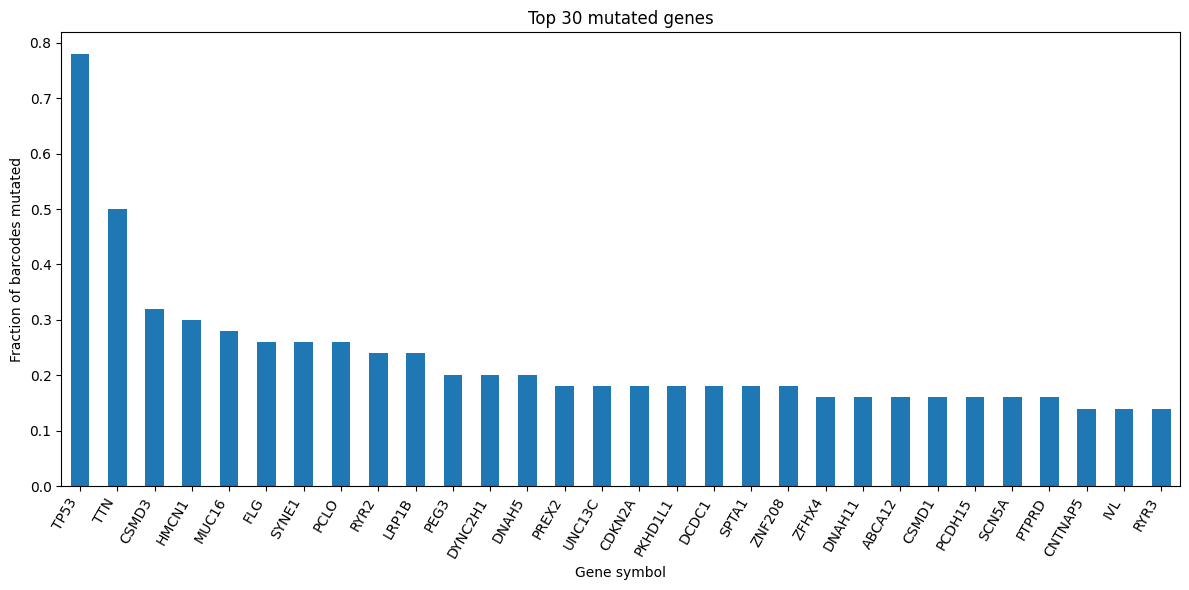

In [49]:
gene_freq = (dfpiv.sum(axis=0) / dfpiv.shape[0]).sort_values(ascending=False)
top_genes = gene_freq.head(top_n)

plt.figure(figsize=(12, 6))
top_genes.plot(kind="bar")
plt.ylabel("Fraction of barcodes mutated")
plt.xlabel("Gene symbol")
plt.title(f"Top {top_n} mutated genes")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

### UMAP cluster

#### Jaccard distance

Jaccard distance is a measure of dissimilarity between two sets, derived directly from Jaccard similarity. While Jaccard similarity measures how much two sets overlap, Jaccard distance measures how different they are. It is defined as one minus the Jaccard similarity.


$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$

In [50]:
from sklearn.metrics import pairwise_distances

X = dfpiv.values.astype(int)   # ensure 0/1
D = pairwise_distances(X, metric="jaccard")

/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


### Hierarchical clustering

In [51]:
from scipy.cluster.hierarchy import linkage

Z = linkage(D, method="average")

/tmp/ipykernel_722756/1243350651.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method="average")


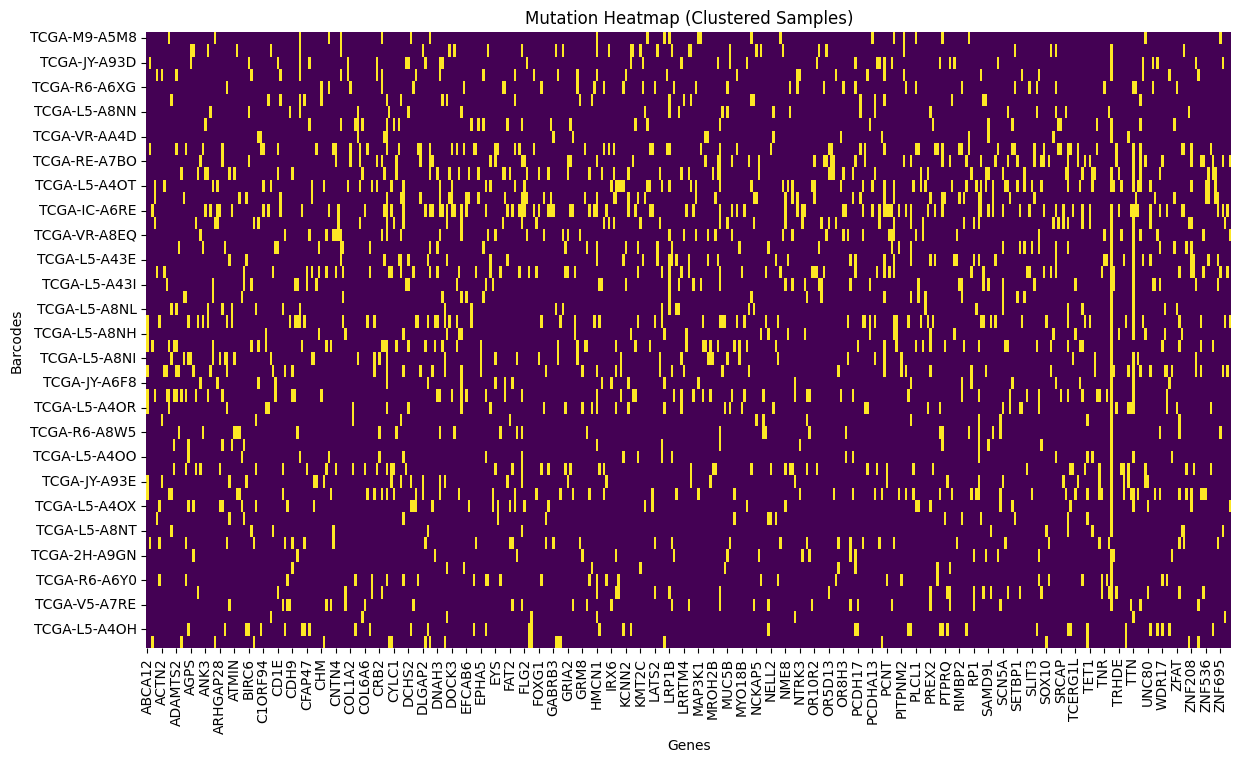

In [53]:
import seaborn as sns

# reorder samples based on clustering
from scipy.cluster.hierarchy import leaves_list
order = leaves_list(Z)

df_ordered = dfpiv.iloc[order]

plt.figure(figsize=(14, 8))
sns.heatmap(df_ordered.astype(int), cmap="viridis", cbar=False)
plt.title("Mutation Heatmap (Clustered Samples)")
plt.xlabel("Genes")
plt.ylabel("Barcodes")
plt.show()

/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


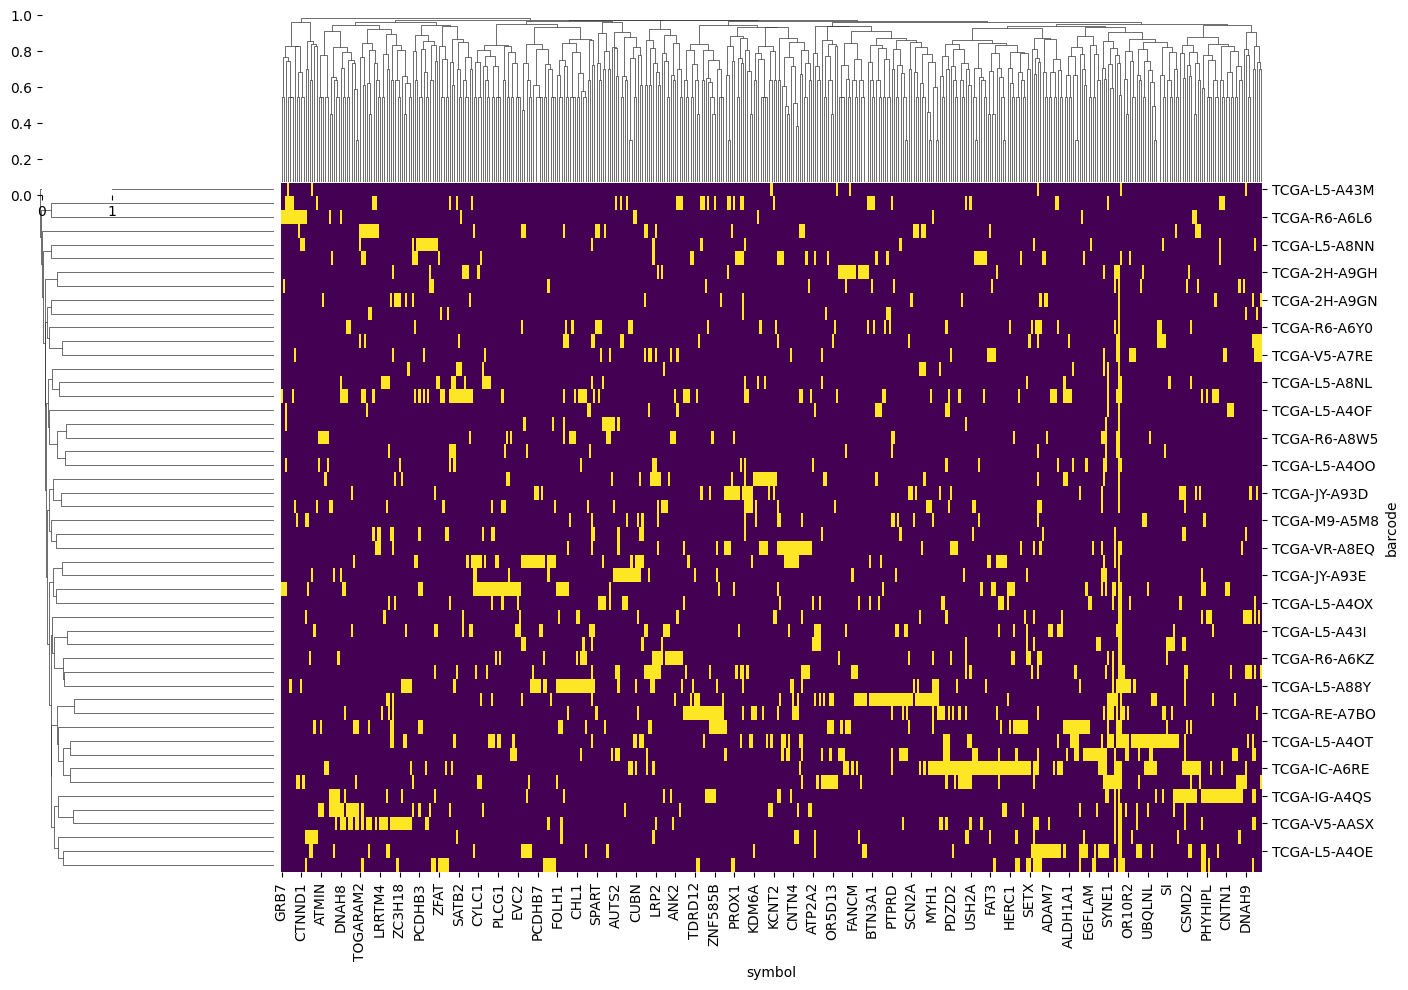

In [54]:
sns.clustermap(
    dfpiv.astype(int),
    metric="jaccard",
    method="average",
    figsize=(14, 10),
    cmap="viridis",
    cbar=False
)

### UMAP

In [55]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="jaccard",
    random_state=42
)

X = dfpiv.values.astype(int)

embedding = reducer.fit_transform(X)

/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [60]:
from sklearn.cluster import KMeans

k = 8  # tune this
labels = KMeans(n_clusters=k, random_state=42).fit_predict(embedding)

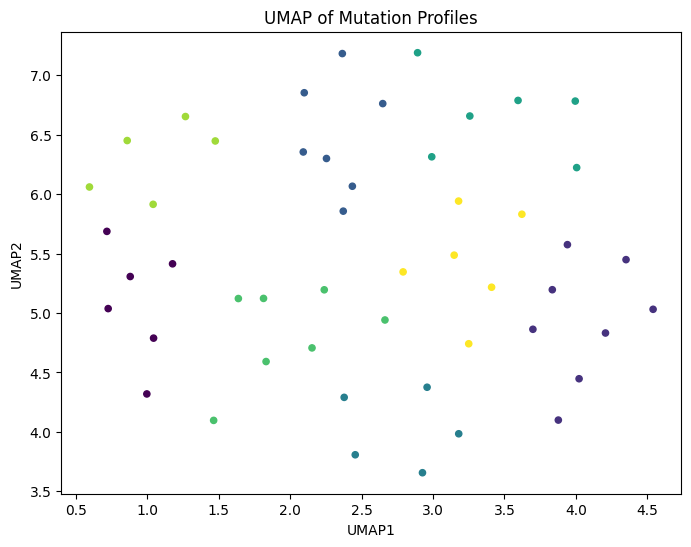

In [ ]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'black', 'cyan']

plt.figure(figsize=(8, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=labels,
    s=20
)
plt.title("UMAP of Mutation Profiles")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

In [ ]:
df_umap = pd.DataFrame(
    embedding,
    index=dfpiv.index,
    columns=["UMAP1", "UMAP2"]
)